In [1]:
import numpy as np
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

In [2]:
SLC_PATH = "Biomass_data/desert_scene/BIO_dessert.hh.slc"
SLC_PAR_PATH = "Biomass_data/desert_scene/BIO_dessert.hh.slc.par"
ANNOT_XML = "Biomass_data/desert_scene/BIO_S2_SCS__1S_20260202T174434_20260202T174457_T_G01_M01_CDR_T026_F137_01_DMKLZR/annotation/bio_s2_scs__1s_20260202t174434_20260202t174457_t_g01_m01_cdr_t026_f137_annot.xml"

In [3]:
#SLC_PATH = "Biomass_data/Test_Scene/20260204.hh.slc"
#SLC_PAR_PATH = "Biomass_data/Test_Scene/20260204.hh.slc.par"
#ANNOT_XML = "Biomass_data/BIO_S2_SCS__1S_20260204T154918_20260204T154941_T_G01_M01_CDR_T010_F183_01_DMKHUB/annotation/bio_s2_scs__1s_20260204t154918_20260204t154941_t_g01_m01_cdr_t010_f183_annot.xml"

In [4]:
# Windowing for CDE DC estimation
WIN_AZ = 512
WIN_RG = 100
STRIDE_AZ = 512
STRIDE_RG = 50

In [5]:
def iso_to_unix(iso_str: str) -> float:
    """
    Convert ISO8601 (no timezone) to unix seconds (assume UTC).
    Example: '2026-02-04T15:49:18.236719'
    """
    dt = datetime.fromisoformat(iso_str).replace(tzinfo=timezone.utc)
    return dt.timestamp()

root = ET.parse(ANNOT_XML).getroot()

t_a0_unix = iso_to_unix(root.findtext(".//firstLineAzimuthTime"))
dt_a = float(root.findtext(".//azimuthTimeInterval"))

F_az = 1.0 / dt_a

In [6]:
def parse_slc_par(par_file):
    params = {}
    with open(par_file, 'r') as f:
        for line in f:
            if ':' in line:
                key, _, val = line.partition(':')
                params[key.strip()] = val.strip().split()
    return params

par = parse_slc_par(SLC_PAR_PATH)

range_samples = int(par['range_samples'][0])
azimuth_lines = int(par['azimuth_lines'][0])

def read_slc(slc_file, range_samples, azimuth_lines):
    dt = np.dtype('>f4')
    raw = np.fromfile(slc_file, dtype=dt)
    complex_data = raw[0::2] + 1j * raw[1::2]
    return complex_data.reshape(azimuth_lines, range_samples)

slc = read_slc(SLC_PATH, range_samples, azimuth_lines)

In [52]:
n_rg = (slc.shape[1] - WIN_RG) // STRIDE_RG + 1
spectrum = np.zeros((WIN_AZ,n_rg))

dcs = []

freqs = np.fft.fftfreq(WIN_AZ, d=1/F_az)
freqs = np.fft.fftshift(freqs)

for i in range(n_rg):
    rg_0 = i * STRIDE_RG
    S = np.fft.fft(slc[000:000+WIN_AZ, rg_0:rg_0+WIN_RG], axis=0)
    S = np.fft.fftshift(S, axes=0) 
    
    S_abs = np.abs(S)**2
    P = np.sum(S_abs, axis=1)
    spectrum[:,i] = P

    f_dc = np.sum(freqs * P) / np.sum(P)
    dcs.append(f_dc)


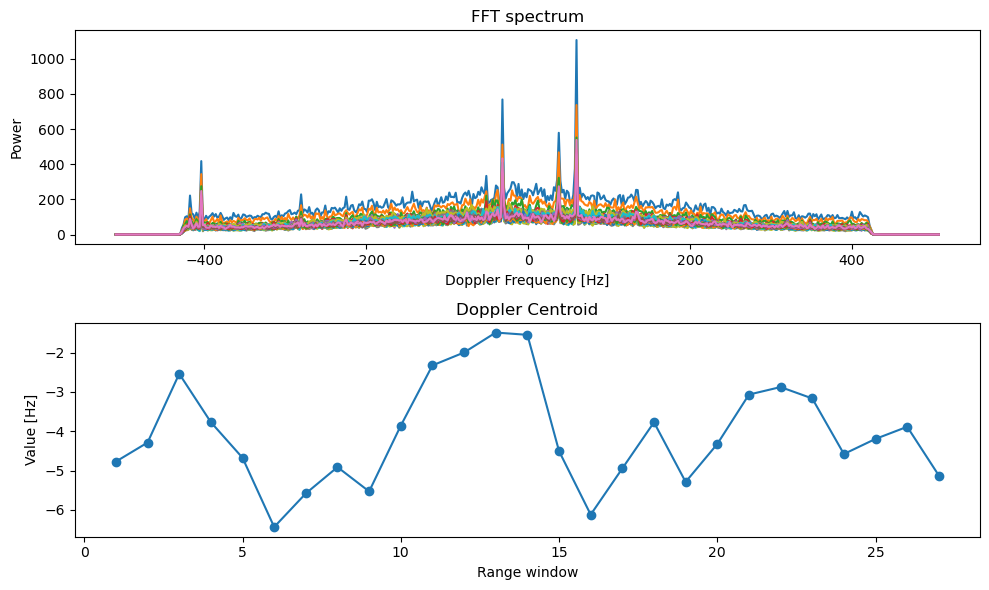

In [53]:
fig,ax = plt.subplots(2,1, figsize=(10,6))
for i in np.arange(1,n_rg-1):
    ax[0].plot(freqs, spectrum[:,i])

ax[0].set_title("FFT spectrum")
ax[0].set_xlabel("Doppler Frequency [Hz]")
ax[0].set_ylabel("Power")

ax[1].plot(np.arange(1,n_rg-1),dcs[1:n_rg-1], marker="o")
ax[1].set_title("Doppler Centroid")
ax[1].set_xlabel("Range window")
ax[1].set_ylabel("Value [Hz]")

plt.tight_layout()

In [22]:
dc_estimates = []
for dc in root.findall(".//dopplerParameters//dcEstimateList//dcEstimate"):
    az_iso = dc.findtext("azimuthTime")
    t0 = dc.findtext("t0")
    poly = dc.findtext("geometryDCPolynomial")

    if az_iso is None or t0 is None or poly is None:
        continue

    az_unix = iso_to_unix(az_iso)
    t0 = float(t0)
    coeffs = np.array([float(x) for x in poly.split()], dtype=np.float64)

    dc_estimates.append((az_unix, t0, coeffs))

In [23]:
def evaluate_dc_polynomial(coeffs, t0, tau):
    dt = tau - t0
    f_dc = 0.0
    for i, c in enumerate(coeffs):
        f_dc = f_dc + c * dt**i
    return f_dc

slant_range_time_0 = float(root.findtext(".//firstSampleSlantRangeTime"))
range_pixel_spacing = float(root.findtext(".//rangeTimeInterval"))
n_samples = float(root.findtext(".//numberOfSamples"))

tau = slant_range_time_0 + np.arange(n_samples) * range_pixel_spacing


In [39]:
df_geom = np.zeros((len(dc_estimates), tau.shape[0]))

for i, entry in enumerate(dc_estimates):
    t0 = entry[1]
    c0, c1, c2, c3, c4 = entry[2]
    for j, t in enumerate(tau):
        df_geom[i, j] = c0 + c1 * (t-t0) + c2 * (t-t0)**2 + c3 * (t-t0)**3 + c4 * (t-t0)**4

In [66]:
tau[0:1]

array([0.00494973])

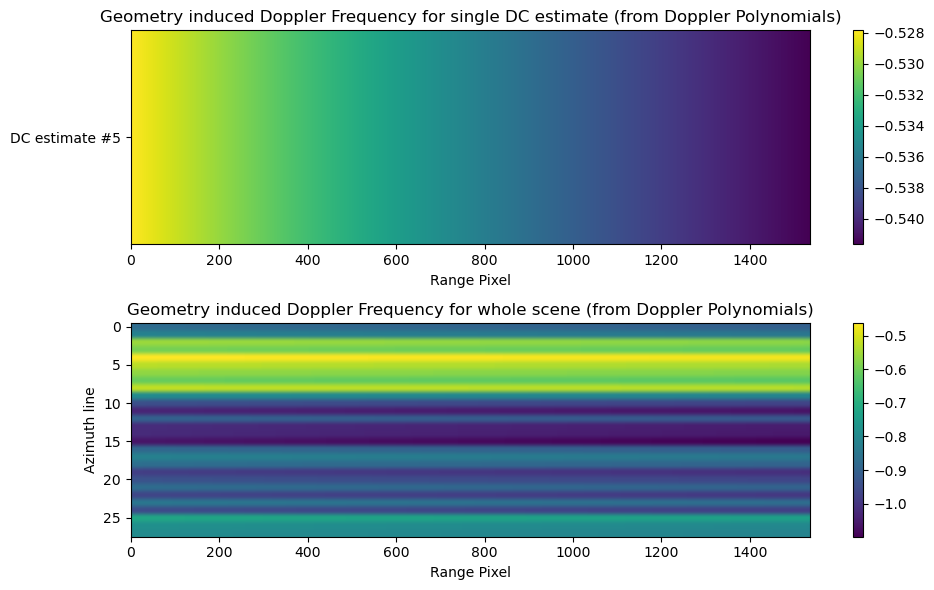

In [ ]:
fig,ax = plt.subplots(2,1, figsize=(10,6))

im1 = ax[0].imshow(df_geom[5:6], aspect='auto')
ax[0].set_title("Geometry induced Doppler Frequency for single DC estimate (from Doppler Polynomials)")
ax[0].set_xlabel("Range Pixel")
ax[0].set_yticks([0])
ax[0].set_yticklabels([f"DC estimate #5/nAzimuth lines: "])
plt.colorbar(im1, ax=ax[0])

im2 = ax[1].imshow(df_geom, aspect='auto')
ax[1].set_title("Geometry induced Doppler Frequency for whole scene (from Doppler Polynomials)")
ax[1].set_xlabel("Range Pixel")
ax[1].set_ylabel("Azimuth line")
plt.colorbar(im2, ax=ax[1])

plt.tight_layout()